In [9]:
import csv

val_losses = {}

with open("./results/1B3_unique_token.csv", "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        val_losses[row["name"]] = float(row["val_loss"])


TOKENS_MAP = {
    "100m": 0.1,
    "130m": 0.13,
    "200m": 0.2,
    "400m": 0.4,
    "800m": 0.8,
    "0b13": 0.13,
    "0b26": 0.26,
    "0b52": 0.52,
    "1b04": 1.04,
    "1b3": 1.3,
    "2b6": 2.6,
    "5b2": 5.2,
    "10b4": 10.4,
    "20b8": 20.8,
    "174b": 174,
    "178b": 178
}

PARAMS_MAP = {
    "44m": 4.4E+07,
    "83m": 8.27E+07,
    "15m": 2.7E+07,
    "30m": 4.5E+07,
    "60m": 8.0E+07,
    "120m": 1.45E+08,
    "240m": 2.68E+08,
    "480m": 5.21E+08,
    "960m": 1.17E+09,
    "1b92": 1.99E+09,
}


DENS_MAP = {
    "s0625": 0.0625,
    "s125": 0.125,
    "s25": 0.25,
    "s5": 0.5,
    "s": 1.0,}

In [10]:
import numpy as np
import matplotlib.pyplot as plt
#import torch
from tqdm import tqdm
#from scaling_law.chinchilladata.datapoints_ours import PARAMS_MAP, TOKENS_MAP, NAMES_TO_VAL_LOSSES, DENS_MAP

model_params = []
tokens = []
unique_tokens = []
losses = []
names = []
epochs = []
densities = []  # 新增稠密度列表

def get_params(name):
    idx = 2
    while name[:idx] not in PARAMS_MAP:
        idx += 1
    params = PARAMS_MAP[name[:idx]]
    return params, idx

def get_unique_tokens(name):
    # 从 name 的结尾向前，尝试找最长匹配 TOKENS_MAP 的 token key
    max_token_len = max(len(k) for k in TOKENS_MAP)
    for l in range(max_token_len, 2, -1):  # 尝试长度从大到小
        ut_candidate = name[-l:]
        if ut_candidate in TOKENS_MAP:
            return TOKENS_MAP[ut_candidate] * 1e9, len(name) - l  # token值, 截取点

    # fallback: 没匹配到合法 key，尝试按 b 为小数点转 float
    ut_fallback = name[-4:]
    ut_val = float(ut_fallback.replace("b", ".").strip("."))
    return ut_val * 1e9, len(name) - 4

def get_tokens(tokens):
    if tokens in TOKENS_MAP:
        tokens = TOKENS_MAP[tokens]
    else:
        tokens = float(tokens.replace("b", ".").strip("."))

    return tokens * 1e9 # Defined in billions

#
def get_density(name):
    for suffix in DENS_MAP:
        if name.endswith(suffix):
            return DENS_MAP[suffix], name[:-len(suffix)]  #
    return 1.0, name  #

#
for name, loss_ in val_losses.items():
    if loss_ != 0 and not name.endswith("dedup"):
        density, trimmed_name = get_density(name)

        p, tok_start_idx = get_params(trimmed_name)
        ut, tok_end_idx = get_unique_tokens(trimmed_name)
        t = get_tokens(trimmed_name[tok_start_idx:tok_end_idx])

        model_params.append(p*density)
        unique_tokens.append(ut)
        tokens.append(t)
        epochs.append(t/ut)
        losses.append(loss_)
        densities.append(density)
        names.append(name)

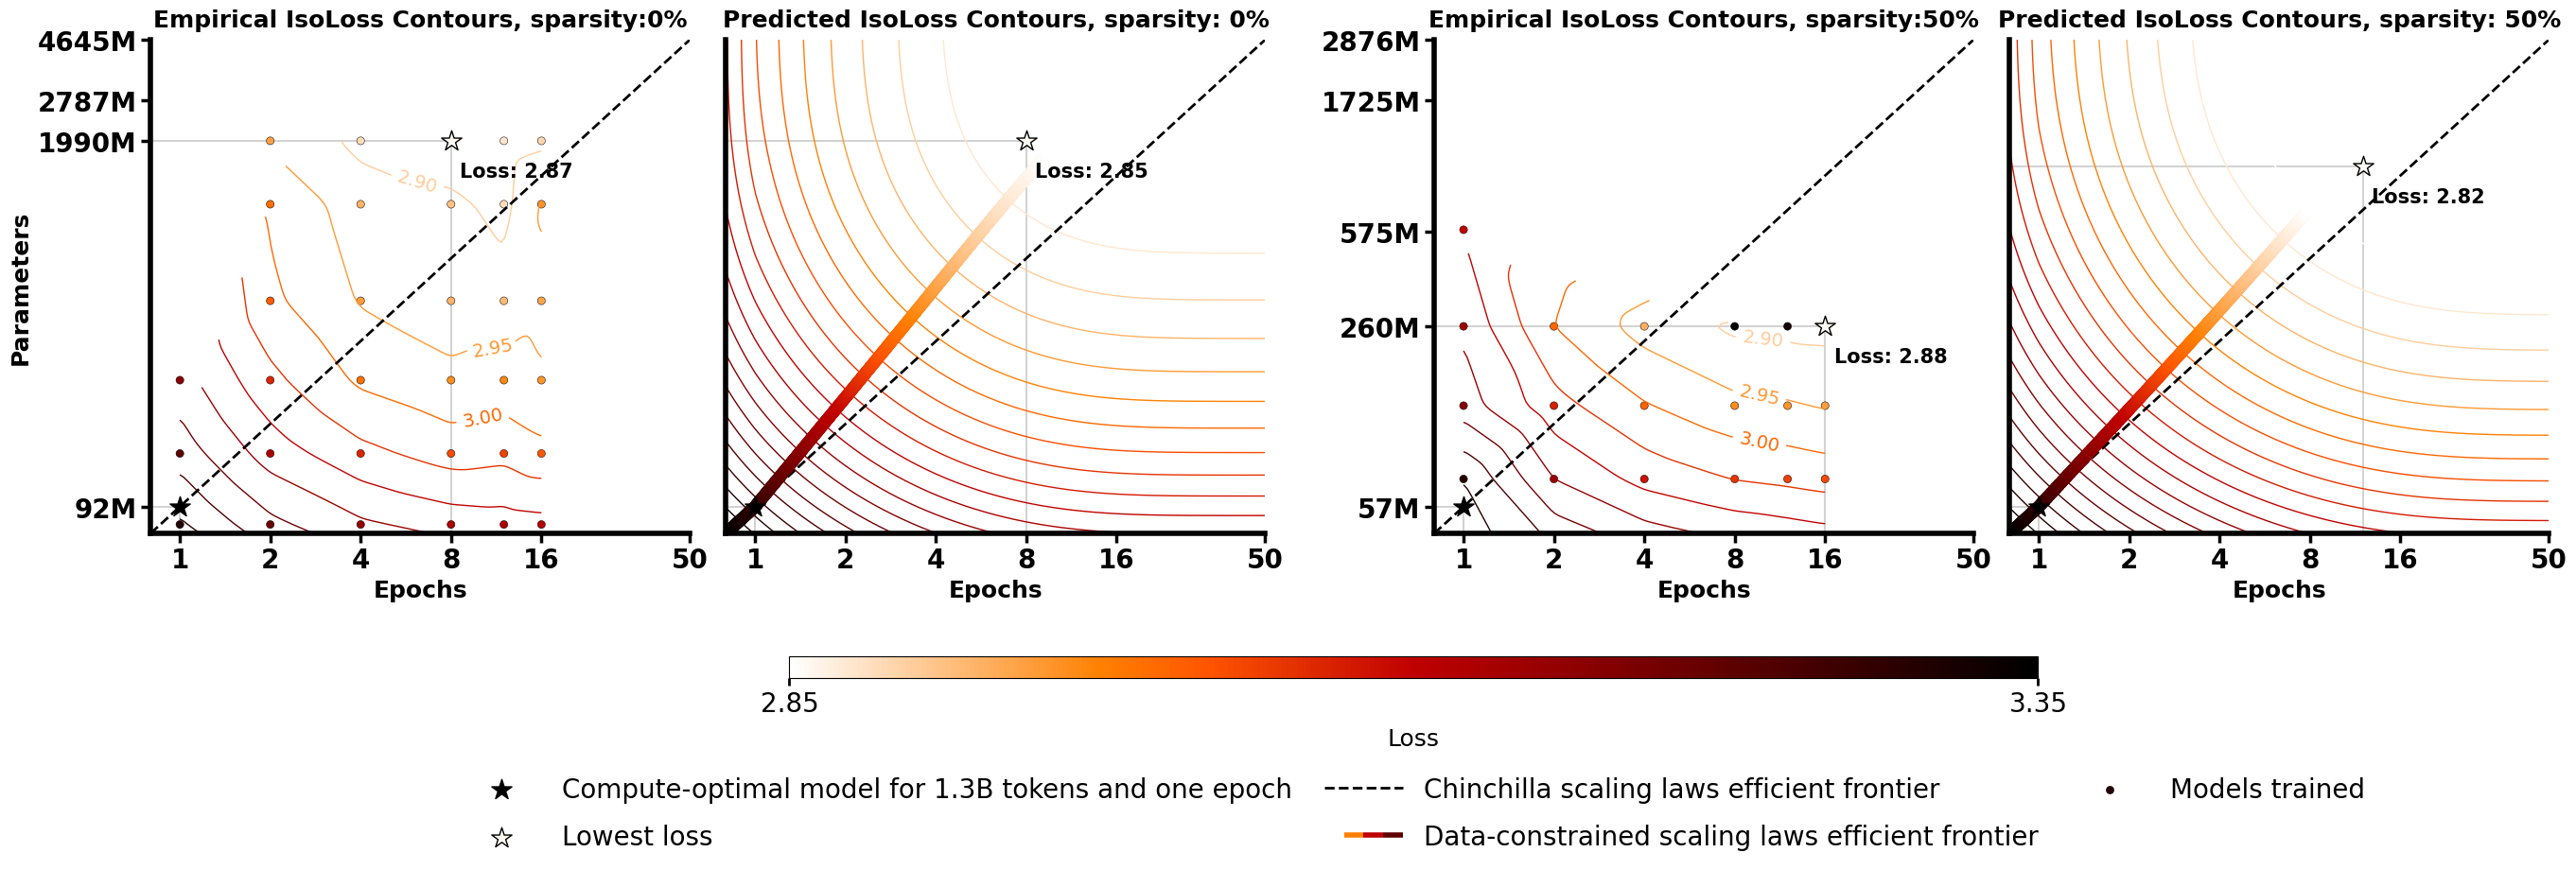

In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.interpolate import griddata
import matplotlib.colors as colors
from matplotlib.legend_handler import HandlerLineCollection
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter

# ============================================================
# Global font settings
# ============================================================
plt.rcParams.update({
    "font.size": 28,
    "axes.labelsize": 34,
    "axes.titlesize": 34,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 25,
    "figure.titlesize": 34,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

LOSS_VMIN = 2.85
LOSS_VMAX = 3.35
LOSS_STEP = 0.05

# ============================================================
# Parameters
# ============================================================
a, b, e, alpha, epsion, mu, c = [
    5.24073718,
    6.10303089,
    0.85355013,
    0.32682177,
    -0.00968044,
    0.84661793,
    -0.27288932,
]

beta = alpha

gamma1, gamma2 = [
    11.08763712,
    4.40474882,
]

c11, c12, c21, c22 = [
    1.90420893,
    1.82159486,
    2.79936732,
    1.36557887,
]

A = np.exp(a)
B = np.exp(b)
E = np.exp(e)

norm_shared = matplotlib.colors.Normalize(
    vmin=LOSS_VMIN,
    vmax=LOSS_VMAX,
)


# ============================================================
# Scaling law helper functions
# ============================================================
def optimal_N(C, s):
    a_exp = beta / (alpha + beta)
    scale = 1

    A_t = (s**epsion + c * (1 - s)**mu) * A
    G = ((alpha * A_t) / (beta * B)) ** (1 / (alpha + beta))

    N_opt = scale * G * (C / 6) ** a_exp
    return N_opt


def N_to_C(N, s):
    a_exp = beta / (alpha + beta)
    scale = 1

    A_t = (s**epsion + c * (1 - s)**mu) * A
    G = ((alpha * A_t) / (beta * B)) ** (1 / (alpha + beta))

    C = ((N / G / scale) ** (1 / a_exp)) * 6
    return C


def optimal_D(C, s):
    b_exp = alpha / (alpha + beta)
    scale = 1

    A_t = (s**epsion + c * (1 - s)**mu) * A
    G = ((alpha * A_t) / (beta * B)) ** (1 / (alpha + beta))

    D_opt = scale * (1 / G) * (C / 6) ** b_exp
    return D_opt


def D_to_C(D, s):
    b_exp = alpha / (alpha + beta)
    scale = 1

    A_t = (s**epsion + c * (1 - s)**mu) * A
    G = ((alpha * A_t) / (beta * B)) ** (1 / (alpha + beta))

    C = ((G * D / scale) ** (1 / b_exp)) * 6
    return C


def scaling_law(N, D, U, S):
    a_, b_, e_, alpha_, epsion_, mu_, c_ = [
        5.24073718,
        6.10303089,
        0.85355013,
        0.32682177,
        -0.00968044,
        0.84661793,
        -0.27288932,
    ]

    beta_ = alpha_

    gamma1_, gamma2_ = [
        11.08763712,
        4.40474882,
    ]

    c11_, c12_, c21_, c22_ = [
        1.90420893,
        1.82159486,
        2.79936732,
        1.36557887,
    ]

    A_ = np.exp(a_)
    B_ = np.exp(b_)
    E_ = np.exp(e_)

    UN = np.minimum(N, optimal_N(D_to_C(U, S), S))

    rn = np.maximum((N / UN) - 1, 0)
    rd = np.maximum((D / U) - 1, 0)

    n_star = gamma1_ * (1 + (1 - S) * c11_ - c21_ * (1 - S) ** 2)
    d_star = gamma2_ * (1 + (1 - S) * c12_ - c22_ * (1 - S) ** 2)

    N_eff = (
        UN + UN * n_star * (1 - np.exp(-rn / n_star))
    ) ** alpha_

    D_eff = (
        U + U * d_star * (1 - np.exp(-rd / d_star))
    ) ** beta_

    L = E_ + A_ * (S**epsion_ + c_ * (1 - S) ** mu_) / N_eff + B_ / D_eff
    return L



# ============================================================
# Combined 4-panel plot:
# S = 1.0 dense + S = 0.5 sparse
# Empirical / Predicted for each setting
# ============================================================

random.seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# Font settings for 4-panel figure
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 22,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,
    "figure.titlesize": 22,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

FONTSIZE = 18
FONTSIZE_SMALL = 20
FONTSIZE_LEGEND = 20
FONTSIZE_CONTOUR = 14
FONTSIZE_ANNOT = 15

CMAP_NAME = "gist_heat_r"

# ------------------------------------------------------------
# Shared loss color scale
# ------------------------------------------------------------
LOSS_VMIN = 2.85
LOSS_VMAX = 3.35
LOSS_STEP = 0.05
CONTOUR_LEVELS = np.arange(LOSS_VMIN, LOSS_VMAX + 1e-9, LOSS_STEP)

CONTOUR_LEVELS = np.arange(
    LOSS_VMIN,
    LOSS_VMAX + 1e-9,
    LOSS_STEP,
)

PREDICTED_CONTOUR_LEVELS = np.arange(
    LOSS_VMIN,
    LOSS_VMAX + 1e-9,
    0.025,
)

# ------------------------------------------------------------
# Figure: 1 x 4 panels
# ------------------------------------------------------------
# fig, axs = plt.subplots(
#     nrows=1,
#     ncols=4,
#     figsize=(30, 9),
# )

fig = plt.figure(figsize=(30, 9))

gs = fig.add_gridspec(
    1,
    5,
    width_ratios=[1, 1, 0.18, 1, 1],
    wspace=0.08,
)

ax_dense_data = fig.add_subplot(gs[0, 0])
ax_dense_fit = fig.add_subplot(gs[0, 1])
ax_sparse_data = fig.add_subplot(gs[0, 3])
ax_sparse_fit = fig.add_subplot(gs[0, 4])

axs = [ax_dense_data, ax_dense_fit, ax_sparse_data, ax_sparse_fit]

ax_dense_data = axs[0]
ax_dense_fit = axs[1]
ax_sparse_data = axs[2]
ax_sparse_fit = axs[3]

UT = 1.3e9

x_ticks = [1, 2, 4, 8, 16, 50]
x_ticks_loc = [np.log10(x) for x in x_ticks]


# ------------------------------------------------------------
# Helper: truncate colormap
# ------------------------------------------------------------
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc({n},{a:.2f},{b:.2f})".format(
            n=cmap.name,
            a=minval,
            b=maxval,
        ),
        cmap(np.linspace(minval, maxval, n)),
    )
    return new_cmap


# ------------------------------------------------------------
# Helper: plot one S setting into two axes
# ------------------------------------------------------------
def plot_one_setting(
    S,
    ax_data,
    ax_fit,
    predicted_best_epoch,
    predicted_best_params,
    show_ylabel=False,
):
    base_p = optimal_N(D_to_C(UT, S), S)
    base_loss = scaling_law(base_p, UT, UT, S)

    sparsity_pct = (1 - S) * 100

    # --------------------------------------------------------
    # Filter models
    # --------------------------------------------------------
    selected_models = [
        (l_or, e_, p / base_p)
        for l_or, ut, e_, p, s in zip(
            losses,
            unique_tokens,
            epochs,
            model_params,
            densities,
        )
        if (ut == UT and s == S)
    ]

    best = min(selected_models, key=lambda x: x[0])
    best_e = best[1]
    best_p = best[2]

    # --------------------------------------------------------
    # Axis ticks
    # --------------------------------------------------------
    ax_data.set_xticks(x_ticks_loc, x_ticks)
    ax_data.set_xlim(np.log10(0.8), np.log10(50))

    if S == 1.0:
        y_ticks = [1, best_p, 30, 50]
    else:
        y_ticks = [1, 10, best_p, 30, 50]

    y_ticks_str = [str(round(x * base_p))[:-6] + "M" for x in y_ticks]
    y_ticks_loc = [np.log10(x) for x in y_ticks]

    ax_data.set_yticks(y_ticks_loc, y_ticks_str)
    ax_data.set_ylim(np.log10(0.8), np.log10(50))

    ax_fit.set_xticks(x_ticks_loc, x_ticks)
    ax_fit.set_xlim(np.log10(0.8), np.log10(50))
    ax_fit.set_yticks([])
    ax_fit.set_ylim(np.log10(0.8), np.log10(50))

    for ax in [ax_data, ax_fit]:
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=FONTSIZE_SMALL,
            width=2.5,
            length=7,
        )
        for tick in ax.get_xticklabels():
            tick.set_fontweight("bold")

        for tick in ax.get_yticklabels():
            tick.set_fontweight("bold")

    # --------------------------------------------------------
    # Empirical contour interpolation
    # --------------------------------------------------------
    eps, ps, ls = [], [], []

    for p, e_, l, ut, s in zip(
        model_params,
        epochs,
        losses,
        unique_tokens,
        densities,
    ):
        if ut == UT and s == S:
            ps.append(p / base_p)
            eps.append(e_)
            ls.append(l / base_loss)

    eps = np.array(eps)
    ps = np.array(ps)
    ls = np.array(ls)

    log_eps = np.log10(eps)
    log_ps = np.log10(ps)
    log_ls = np.log10(ls)

    xg = np.linspace(log_eps.min(), log_eps.max(), 100)
    yg = np.linspace(log_ps.min(), log_ps.max(), 100)

    epochs_mesh, params_mesh = np.meshgrid(xg, yg)

    losses_interp = griddata(
        (log_eps, log_ps),
        log_ls,
        (epochs_mesh, params_mesh),
        method="linear",
    )

    losses_interp = gaussian_filter(losses_interp, sigma=1.0)
    losses_interp = np.ma.array(losses_interp, mask=np.isnan(losses_interp))

    loss_grid = (10**losses_interp) * base_loss
    min_loss = np.ma.min(loss_grid)

    contours_data = ax_data.contour(
        epochs_mesh,
        params_mesh,
        loss_grid,
        levels=CONTOUR_LEVELS,
        cmap=CMAP_NAME,
        norm=norm_shared,
        extend="both",
        linewidths=1.0,
    )

    ax_data.clabel(
        contours_data,
        levels=contours_data.levels[:4],
        inline=True,
        fontsize=FONTSIZE_CONTOUR,
        fmt="%1.2f",
    )

    # --------------------------------------------------------
    # Empirical scatter points
    # --------------------------------------------------------
    in_range = [
        x
        for x in selected_models
        if min_loss < x[0] < min_loss + 1
    ]

    out_range = [
        x
        for x in selected_models
        if not (min_loss < x[0] < min_loss + 1)
    ]

    ax_data.scatter(
        np.log10([x[1] for x in in_range]),
        np.log10([x[2] for x in in_range]),
        s=35,
        c=[x[0] for x in in_range],
        cmap=CMAP_NAME,
        norm=norm_shared,
        edgecolor="black",
        linewidth=0.35,
    )

    outer_cmap = truncate_colormap(plt.get_cmap(CMAP_NAME), 0.9, 1.0)

    ax_data.scatter(
        np.log10([x[1] for x in out_range]),
        np.log10([x[2] for x in out_range]),
        s=35,
        label="Models trained",
        c=[x[0] for x in out_range],
        cmap=outer_cmap,
        edgecolor="black",
        linewidth=0.35,
    )

    # --------------------------------------------------------
    # Empirical stars
    # --------------------------------------------------------
    ax_data.scatter(
        [np.log10(1)],
        [np.log10(1)],
        s=260,
        marker="*",
        color="black",
        edgecolor="black",
        label="Compute-optimal model for 1.3B tokens and one epoch",
        zorder=10,
    )

    ax_data.annotate(
        f"Loss: {round(base_loss, 2)}",
        (np.log10(1) + 0.13, np.log10(1) - 0.10),
        fontsize=FONTSIZE_ANNOT,
        weight="bold",
    )

    ax_data.scatter(
        [np.log10(best_e)],
        [np.log10(best_p)],
        s=260,
        marker="*",
        color="#fff9f3",
        edgecolor="black",
        label="Lowest loss",
        zorder=10,
    )

    ax_data.annotate(
        f"Loss: {round(best[0], 2)}",
        (np.log10(best_e) + 0.03, np.log10(best_p) - 0.13),
        fontsize=FONTSIZE_ANNOT,
        weight="bold",
    )

    # helper lines
    ax_data.vlines(
        x=np.log10(best_e),
        ymin=-10,
        ymax=np.log10(best_p),
        color="lightgrey",
        zorder=-1,
        linestyle="-",
        linewidth=1.5,
    )

    ax_data.hlines(
        y=np.log10(best_p),
        xmin=-10,
        xmax=np.log10(best_e),
        color="lightgrey",
        zorder=-1,
        linestyle="-",
        linewidth=1.5,
    )

    ax_data.vlines(
        x=np.log10(1),
        ymin=-10,
        ymax=np.log10(1),
        color="lightgrey",
        zorder=-1,
        linestyle="-",
        linewidth=1.5,
    )

    ax_data.hlines(
        y=np.log10(1),
        xmin=-10,
        xmax=np.log10(1),
        color="lightgrey",
        zorder=-1,
        linestyle="-",
        linewidth=1.5,
    )

    # --------------------------------------------------------
    # Chinchilla frontier
    # --------------------------------------------------------
    MIN_PARAMS, MAX_PARAMS = 1e8, 11e12
    MIN_TOKS, MAX_TOKS = 1e8, 11e12

    f_min = MIN_PARAMS * MIN_TOKS * 6
    f_max = MAX_PARAMS * MAX_TOKS * 6

    c_c4 = np.logspace(np.log10(f_min), np.log10(f_max), 4000)

    toks_c4 = np.log10(np.array([
        optimal_D(x, S) / UT
        for x in c_c4
    ]))

    size_c4 = np.log10(np.array([
        optimal_N(x, S) / base_p
        for x in c_c4
    ]))

    ax_data.plot(
        toks_c4,
        size_c4,
        label="Chinchilla scaling laws efficient frontier",
        color="black",
        linestyle="--",
        linewidth=2.0,
    )

    ax_data.set_title(
        f"Empirical IsoLoss Contours, sparsity:{sparsity_pct:.0f}%",
        fontsize=FONTSIZE,
        fontweight="bold",
        pad=10,
    )

    # --------------------------------------------------------
    # Predicted contour
    # --------------------------------------------------------
    es = np.logspace(np.log10(0.1), np.log10(1000), 1000)
    ps_grid = es

    X, Y = np.meshgrid(es, ps_grid)

    Z = scaling_law(
        Y * base_p,
        X * UT,
        np.minimum(X * UT, UT),
        S,
    )

    contours_fit = ax_fit.contour(
        np.log10(X),
        np.log10(Y),
        Z,
        levels=PREDICTED_CONTOUR_LEVELS,
        cmap=CMAP_NAME,
        norm=norm_shared,
        extend="both",
        linewidths=1.0,
    )

    ax_fit.clabel(
        contours_fit,
        levels=contours_fit.levels[:4],
        inline=True,
        fontsize=FONTSIZE_CONTOUR,
        fmt="%1.2f",
    )

    ax_fit.scatter(
        [np.log10(1)],
        [np.log10(1)],
        s=260,
        marker="*",
        color="black",
        edgecolor="black",
        label="Compute-optimal model for 1.3B tokens and one epoch",
        zorder=10,
    )

    ax_fit.scatter(
        [np.log10(predicted_best_epoch)],
        [np.log10(predicted_best_params / base_p)],
        s=260,
        marker="*",
        color="#fff9f3",
        edgecolor="black",
        label="Lowest loss",
        zorder=10,
    )

    ax_fit.vlines(
        x=np.log10(predicted_best_epoch),
        ymin=-10,
        ymax=np.log10(predicted_best_params / base_p),
        color="lightgrey",
        zorder=-1,
        linestyle="-",
        linewidth=1.5,
    )

    ax_fit.hlines(
        y=np.log10(predicted_best_params / base_p),
        xmin=-10,
        xmax=np.log10(predicted_best_epoch),
        color="lightgrey",
        zorder=-1,
        linestyle="-",
        linewidth=1.5,
    )

    ax_fit.vlines(
        x=np.log10(1),
        ymin=-10,
        ymax=np.log10(1),
        color="lightgrey",
        zorder=-1,
        linestyle="-",
        linewidth=1.5,
    )

    ax_fit.hlines(
        y=np.log10(1),
        xmin=-10,
        xmax=np.log10(1),
        color="lightgrey",
        zorder=-1,
        linestyle="-",
        linewidth=1.5,
    )

    ax_fit.annotate(
        f"Loss: {round(scaling_law(predicted_best_params, predicted_best_epoch * UT, UT, S), 2)}",
        (
            np.log10(predicted_best_epoch) + 0.03,
            np.log10(predicted_best_params / base_p) - 0.13,
        ),
        fontsize=FONTSIZE_ANNOT,
        weight="bold",
    )

    ax_fit.plot(
        toks_c4,
        size_c4,
        label="Chinchilla scaling laws efficient frontier",
        color="black",
        linestyle="--",
        linewidth=2.0,
    )

    # --------------------------------------------------------
    # Data-constrained efficient frontier
    # --------------------------------------------------------
    toks_opt = []
    size_opt = []
    loss_opt = []

    last_l = float("inf")

    toks_c4_raw = np.array([
        optimal_D(x, S)
        for x in c_c4
    ])

    size_c4_raw = np.array([
        optimal_N(x, S)
        for x in c_c4
    ])

    start_t, end_t = ax_fit.get_xlim()
    start_s, end_s = ax_fit.get_ylim()

    for t, s_ in zip(toks_c4_raw, size_c4_raw):
        if not (start_t <= np.log10(t / UT) <= end_t):
            continue

        if not (start_s <= np.log10(s_ / base_p) <= end_s):
            continue

        min_l = scaling_law(s_, t, min(UT, t), S)
        min_t = t
        min_s = s_

        for i in np.linspace(1.001, 3, 1000):
            D = t * i
            U = min(UT, D)
            N = s_ / i

            new_l = scaling_law(N, D, U, S)

            if new_l < min_l:
                min_l = new_l
                min_t = D
                min_s = N

            D = t / i
            U = min(UT, D)
            N = s_ * i

            new_l = scaling_law(N, D, U, S)

            if new_l < min_l:
                min_l = new_l
                min_t = D
                min_s = N

        if min_l >= last_l:
            break

        toks_opt.append(min_t / UT)
        size_opt.append(min_s / base_p)
        loss_opt.append(min_l)

        last_l = min_l

    ax_fit.scatter(
        np.log10([
            t
            for t, l in zip(toks_opt, loss_opt)
            if LOSS_VMIN <= l <= LOSS_VMAX
        ]),
        np.log10([
            s_
            for s_, l in zip(size_opt, loss_opt)
            if LOSS_VMIN <= l <= LOSS_VMAX
        ]),
        s=70,
        c=[
            l
            for l in loss_opt
            if LOSS_VMIN <= l <= LOSS_VMAX
        ],
        cmap=CMAP_NAME,
        norm=norm_shared,
        zorder=2,
    )

    ax_fit.plot(
        [],
        [],
        color="black",
        label="Data-constrained scaling laws efficient frontier",
        linewidth=4,
    )

    ax_fit.set_title(
        f"Predicted IsoLoss Contours, sparsity: {sparsity_pct:.0f}%",
        fontsize=FONTSIZE,
        fontweight="bold",
        pad=10,
    )

    # --------------------------------------------------------
    # Final styling for this pair
    # --------------------------------------------------------
    for ax in [ax_data, ax_fit]:
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)

        for spine in ax.spines.values():
            spine.set_linewidth(4.0)

        ax.set_xlabel(
            "Epochs",
            fontsize=FONTSIZE,
            fontweight="bold"
        )

    if show_ylabel:
        ax_data.set_ylabel(
            "Parameters",
            fontsize=FONTSIZE,
            fontweight="bold"
        )

    return contours_fit


# ============================================================
# Draw the four panels
# ============================================================

# Dense, sparsity 0%
contours_dense = plot_one_setting(
    S=1.0,
    ax_data=ax_dense_data,
    ax_fit=ax_dense_fit,
    predicted_best_epoch=8,
    predicted_best_params=1990e6,
    show_ylabel=True,
)

# Sparse, sparsity 50%
contours_sparse = plot_one_setting(
    S=0.5,
    ax_data=ax_sparse_data,
    ax_fit=ax_sparse_fit,
    predicted_best_epoch=12,
    predicted_best_params=995e6,
    show_ylabel=False,
)

norm_shared = matplotlib.colors.Normalize(
    vmin=LOSS_VMIN,
    vmax=LOSS_VMAX,
)

# ============================================================
# Shared colorbar
# ============================================================
sm = plt.cm.ScalarMappable(
    norm=norm_shared,
    cmap=plt.get_cmap(CMAP_NAME),
)

sm.set_array([])

# cbar_ax = fig.add_axes([0.925, 0.30, 0.012, 0.55])
# cbar = fig.colorbar(sm, cax=cbar_ax)

# cbar.ax.set_ylabel(
#     "Loss",
#     rotation=270,
#     fontsize=FONTSIZE,
#     labelpad=28,
# )

# cbar.ax.set_yticks([LOSS_VMIN, LOSS_VMAX])
# cbar.ax.set_ylim((LOSS_VMIN, LOSS_VMAX))

# ============================================================
# Shared colorbar at bottom
# ============================================================
cbar_ax = fig.add_axes([0.28, 0.13, 0.44, 0.025])
cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation="horizontal",
)

cbar.ax.set_xlabel(
    "Loss",
    fontsize=FONTSIZE,
    labelpad=8,
)

cbar.ax.set_xticks([LOSS_VMIN, LOSS_VMAX])
cbar.ax.set_xlim((LOSS_VMIN, LOSS_VMAX))

cbar.ax.tick_params(
    labelsize=FONTSIZE_SMALL,
    width=2.0,
    length=6,
)

cbar.ax.tick_params(
    labelsize=FONTSIZE_SMALL,
    width=2.0,
    length=6,
)


# ============================================================
# Shared legend
# ============================================================
handles, labels = [], []

for ax in axs:
    h_, l_ = ax.get_legend_handles_labels()
    for h, l in zip(h_, l_):
        if l not in labels:
            handles.append(h)
            labels.append(l)

order = [
    "Compute-optimal model for 1.3B tokens and one epoch",
    "Lowest loss",
    "Chinchilla scaling laws efficient frontier",
    "Data-constrained scaling laws efficient frontier",
    "Models trained",
]

handles_ordered = []
labels_ordered = []
to_map = None

for o in order:
    for h, l in zip(handles, labels):
        if l == "Data-constrained scaling laws efficient frontier":
            to_map = h

        if l == o:
            handles_ordered.append(h)
            labels_ordered.append(l)
            break


class HandlerColorLineCollection(HandlerLineCollection):
    def create_artists(
        self,
        legend,
        artist,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        x = np.linspace(0, width, self.get_numpoints(legend) + 1)
        y = np.zeros(self.get_numpoints(legend) + 1) + height / 2.0 - ydescent

        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(
            segments,
            cmap=CMAP_NAME,
            transform=trans,
        )

        lc.set_array(x)
        lc.set_linewidth(artist.get_linewidth())

        return [lc]


handler_map = {}
if to_map is not None:
    handler_map[to_map] = HandlerColorLineCollection(numpoints=4)

fig.legend(
    handles_ordered,
    labels_ordered,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False,
    fontsize=FONTSIZE_LEGEND,
    handler_map=handler_map,
    handlelength=3.0,
    handletextpad=0.8,
    columnspacing=1.2,
    labelspacing=0.8,
)


# ============================================================
# Layout and save
# ============================================================
plt.subplots_adjust(
    left=0.055,
    right=0.90,
    top=0.88,
    bottom=0.3,
    wspace=0.16,
)

plt.savefig(
    "isoloss_combined_dense_sparse.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "isoloss_combined_dense_sparse.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    "isoloss_combined_dense_sparse.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()